In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/mariospirito/position-salariescsv/Position_Salaries.csv


# 1. Load and Inspect

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('/kaggle/input/datasets/mariospirito/position-salariescsv/Position_Salaries.csv')
df.head()

,Position,Level,Salary
0,Business Analyst,1,45000
1,Junior Consultant,2,50000
2,Senior Consultant,3,60000
3,Manager,4,80000
4,Country Manager,5,110000


In [4]:
df

,Position,Level,Salary
0,Business Analyst,1,45000
1,Junior Consultant,2,50000
2,Senior Consultant,3,60000
3,Manager,4,80000
4,Country Manager,5,110000
5,Region Manager,6,150000
6,Partner,7,200000
7,Senior Partner,8,300000
8,C-level,9,500000
9,CEO,10,1000000


In [5]:
df.describe()

,Level,Salary
count,10.00000,10.000000
mean,5.50000,249500.000000
std,3.02765,299373.883668
min,1.00000,45000.000000
25%,3.25000,65000.000000
50%,5.50000,130000.000000
75%,7.75000,275000.000000
max,10.00000,1000000.000000


we can drop position as level is donating the same thing.

In [6]:
df = df.drop(columns=['Position'])

In [7]:
df

,Level,Salary
0,1,45000
1,2,50000
2,3,60000
3,4,80000
4,5,110000
5,6,150000
6,7,200000
7,8,300000
8,9,500000
9,10,1000000


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Level   10 non-null     int64
 1   Salary  10 non-null     int64
dtypes: int64(2)
memory usage: 292.0 bytes


# 2. Plot the graph to see the pattern

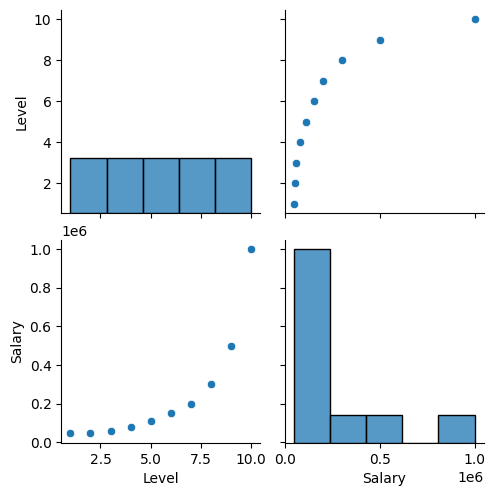

In [9]:
sns.pairplot(df)

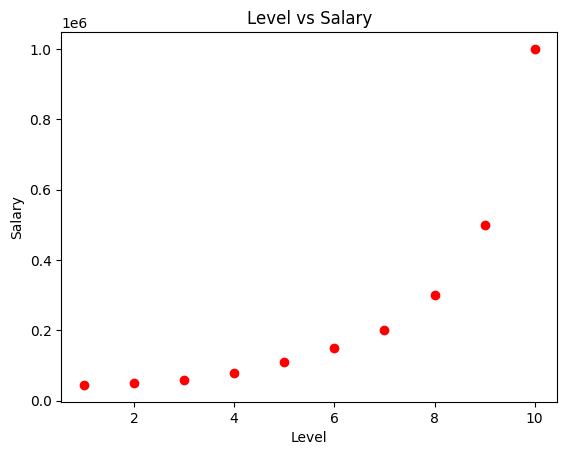

In [10]:
plt.scatter(df['Level'], df['Salary'], color='red')
plt.xlabel('Level')
plt.ylabel('Salary')
plt.title('Level vs Salary')
plt.show()

# 3. Fit Linear Regression first

Note: here we are not performing any train-test split as it's for strengthening the concept of polynomial regression and also as this dataset has only 10 rows.

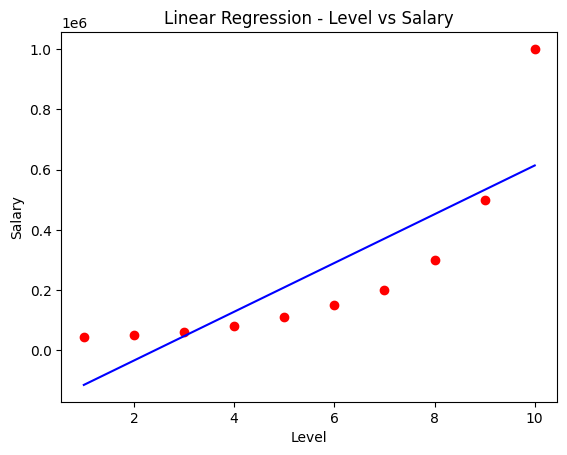

In [11]:
from sklearn.linear_model import LinearRegression

X = df[['Level']]
y = df['Salary']

lin_reg = LinearRegression()
lin_reg.fit(X,y)

plt.scatter(X, y, color='red')
plt.plot(X, lin_reg.predict(X), color='blue')
plt.title('Linear Regression - Level vs Salary')
plt.xlabel('Level')
plt.ylabel('Salary')
plt.show()

# Polynomial Regression

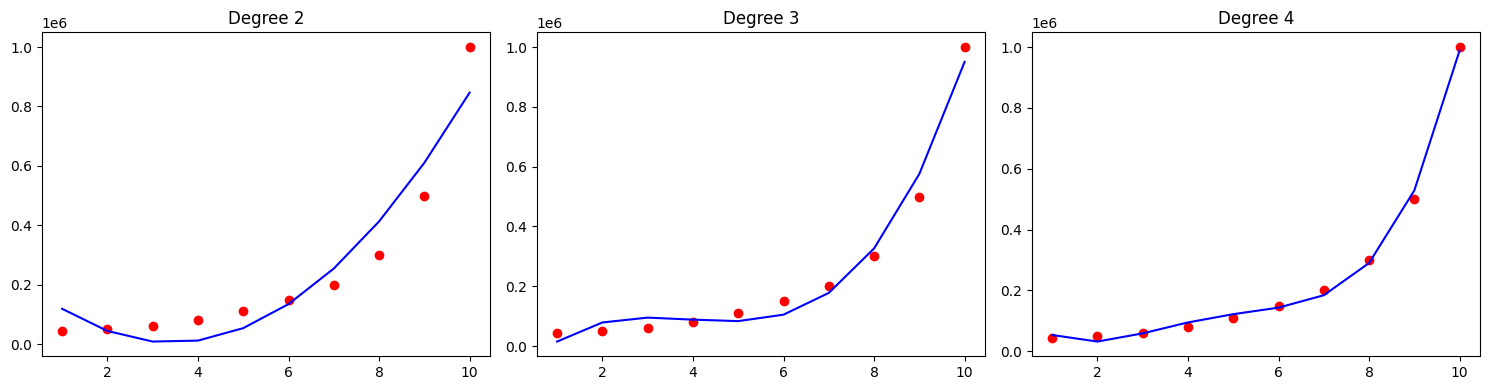

In [12]:
from sklearn.preprocessing import PolynomialFeatures

fig, axes= plt.subplots(1,3, figsize=(15,4))
for i, degree in enumerate([2,3,4]):
    poly = PolynomialFeatures(degree= degree)
    X_poly = poly.fit_transform(X)

    poly_reg = LinearRegression()
    poly_reg.fit(X_poly, y)

    axes[i].scatter(X, y, color='red')
    axes[i].plot(X, poly_reg.predict(X_poly), color='blue')
    axes[i].set_title(f'Degree {degree}')
plt.tight_layout()
plt.show()

Plotting multiple degrees side by side lets you visually see the curve tighten around the actual points as degree increases

# Final comparison — R²

In [13]:
from sklearn.metrics import r2_score

lin_r2 = r2_score(y, lin_reg.predict(X))
print("Linear Regression R²:", lin_r2)

poly4 = PolynomialFeatures(degree=4)
X_poly4 = poly4.fit_transform(X)
poly_reg4 = LinearRegression()
poly_reg4.fit(X_poly4, y)
poly_r2 = r2_score(y, poly_reg4.predict(X_poly4))

print("Polynomial (degree 4) R²:", poly_r2)

Linear Regression R²: 0.6690412331929895
Polynomial (degree 4) R²: 0.9973922891706614


# Check for overfitting

With only 10 data points, checking how R² changes across degrees 2-6 helps confirm whether degree 4 is a genuine "sweet spot" or whether we're already starting to memorize individual points — a real risk given how few rows this dataset has

In [14]:
for degree in [2, 3, 4, 5, 6]:
    poly = PolynomialFeatures(degree=degree)
    X_poly = poly.fit_transform(X)
    model = LinearRegression().fit(X_poly, y)
    r2 = r2_score(y, model.predict(X_poly))
    print(f"Degree {degree}: R² = {r2:.4f}")

Degree 2: R² = 0.9162
Degree 3: R² = 0.9812
Degree 4: R² = 0.9974
Degree 5: R² = 0.9998
Degree 6: R² = 0.9999
